In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Upload dataset
from google.colab import files
uploaded = files.upload()

# Read dataset
df = pd.read_csv(list(uploaded.keys())[0])

# Show first 5 rows
df.head()

Saving crime_raw.csv.csv to crime_raw.csv.csv


,Unnamed: 0,State,Year,Rape,K&A,DD,AoW,AoM,DV,WT
0,0,ANDHRA PRADESH,2001,871,765,420,3544,2271,5791,7
1,1,ARUNACHAL PRADESH,2001,33,55,0,78,3,11,0
2,2,ASSAM,2001,817,1070,59,850,4,1248,0
3,3,BIHAR,2001,888,518,859,562,21,1558,83
4,4,CHHATTISGARH,2001,959,171,70,1763,161,840,0


In [ ]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 736 entries, 0 to 735
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  736 non-null    int64 
 1   State       736 non-null    object
 2   Year        736 non-null    int64 
 3   Rape        736 non-null    int64 
 4   K&A         736 non-null    int64 
 5   DD          736 non-null    int64 
 6   AoW         736 non-null    int64 
 7   AoM         736 non-null    int64 
 8   DV          736 non-null    int64 
 9   WT          736 non-null    int64 
dtypes: int64(9), object(1)
memory usage: 57.6+ KB


,0
Unnamed: 0,0
State,0
Year,0
Rape,0
K&A,0
DD,0
AoW,0
AoM,0
DV,0
WT,0


In [ ]:
# Drop unnecessary column
df = df.drop(columns=['Unnamed: 0'])

# Check again
df.head()

,State,Year,Rape,K&A,DD,AoW,AoM,DV,WT
0,ANDHRA PRADESH,2001,871,765,420,3544,2271,5791,7
1,ARUNACHAL PRADESH,2001,33,55,0,78,3,11,0
2,ASSAM,2001,817,1070,59,850,4,1248,0
3,BIHAR,2001,888,518,859,562,21,1558,83
4,CHHATTISGARH,2001,959,171,70,1763,161,840,0


In [ ]:
# Create total crime column
df['Total_Crime'] = df[['Rape','K&A','DD','AoW','AoM','DV','WT']].sum(axis=1)

df.head()

,State,Year,Rape,K&A,DD,AoW,AoM,DV,WT,Total_Crime
0,ANDHRA PRADESH,2001,871,765,420,3544,2271,5791,7,13669
1,ARUNACHAL PRADESH,2001,33,55,0,78,3,11,0,180
2,ASSAM,2001,817,1070,59,850,4,1248,0,4048
3,BIHAR,2001,888,518,859,562,21,1558,83,4489
4,CHHATTISGARH,2001,959,171,70,1763,161,840,0,3964


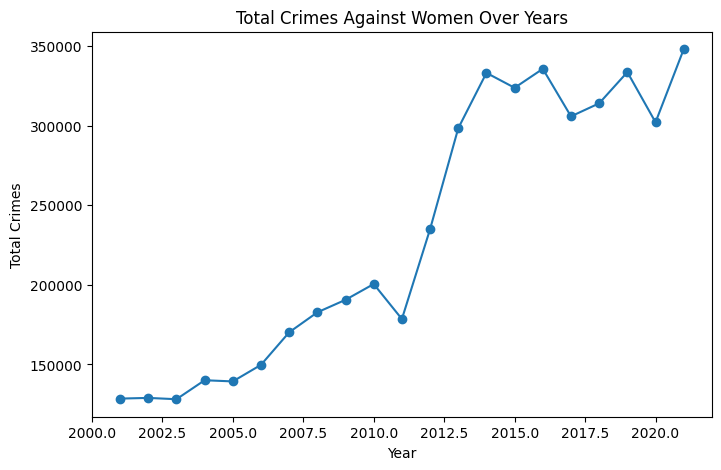

In [ ]:
yearly = df.groupby('Year')['Total_Crime'].sum()

plt.figure(figsize=(8,5))
plt.plot(yearly, marker='o')
plt.title("Total Crimes Against Women Over Years")
plt.xlabel("Year")
plt.ylabel("Total Crimes")
plt.show()

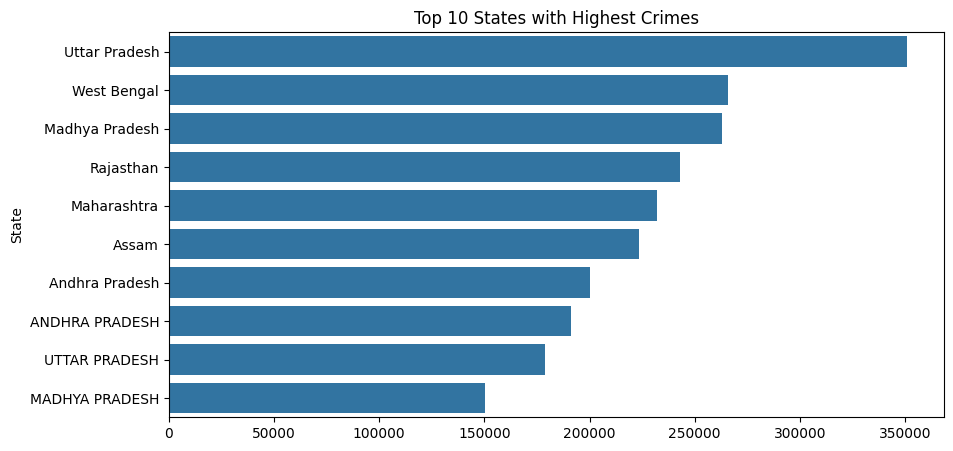

In [ ]:
state_data = df.groupby('State')['Total_Crime'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=state_data.values, y=state_data.index)
plt.title("Top 10 States with Highest Crimes")
plt.show()

In [ ]:
# Convert all state names to lowercase
df['State'] = df['State'].str.lower()

# Convert to proper format (Title Case)
df['State'] = df['State'].str.title()

df['State'].unique()

array(['Andhra Pradesh', 'Arunachal Pradesh', 'Assam', 'Bihar',
       'Chhattisgarh', 'Goa', 'Gujarat', 'Haryana', 'Himachal Pradesh',
       'Jammu & Kashmir', 'Jharkhand', 'Karnataka', 'Kerala',
       'Madhya Pradesh', 'Maharashtra', 'Manipur', 'Meghalaya', 'Mizoram',
       'Nagaland', 'Odisha', 'Punjab', 'Rajasthan', 'Sikkim',
       'Tamil Nadu', 'Tripura', 'Uttar Pradesh', 'Uttarakhand',
       'West Bengal', 'A & N Islands', 'Chandigarh', 'D & N Haveli',
       'Daman & Diu', 'Lakshadweep', 'Puducherry', 'Telangana',
       'D&N Haveli', 'Delhi Ut'], dtype=object)

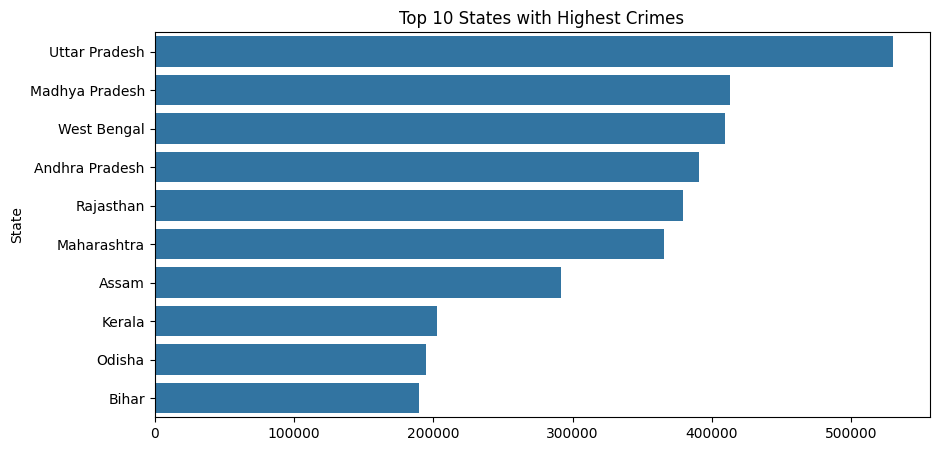

In [ ]:
state_data = df.groupby('State')['Total_Crime'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=state_data.values, y=state_data.index)
plt.title("Top 10 States with Highest Crimes")
plt.show()

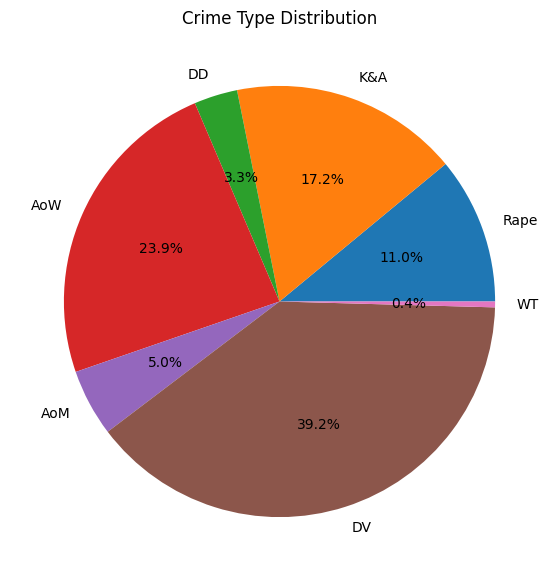

In [ ]:
crime_types = df[['Rape','K&A','DD','AoW','AoM','DV','WT']].sum()

plt.figure(figsize=(7,7))
plt.pie(crime_types, labels=crime_types.index, autopct='%1.1f%%')
plt.title("Crime Type Distribution")
plt.show()

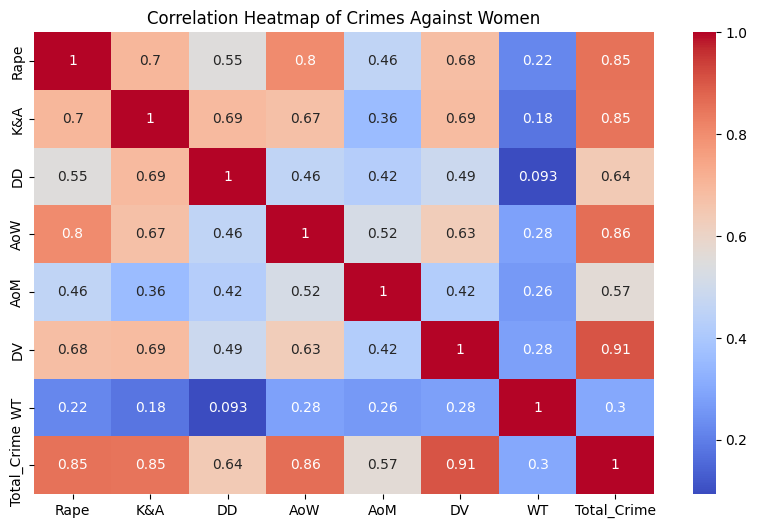

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select only crime columns (remove State, Year, etc.)
crime_data = df.drop(['State', 'Year'], axis=1)

# Create correlation matrix
corr = crime_data.corr()

# Plot heatmap
plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap of Crimes Against Women")
plt.show()

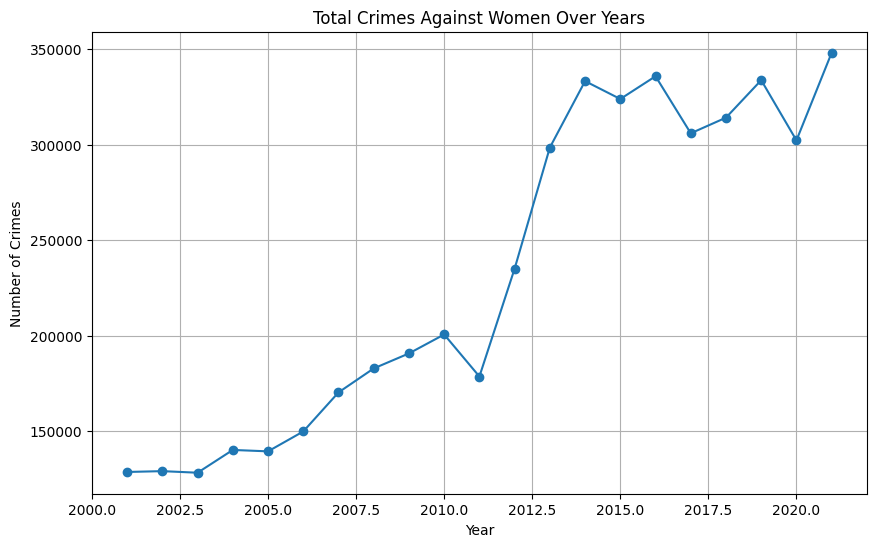

In [ ]:
# Group data by Year
yearly_data = df.groupby('Year').sum()

# Plot total crimes over years
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.plot(yearly_data.index, yearly_data['Total_Crime'], marker='o')

plt.title("Total Crimes Against Women Over Years")
plt.xlabel("Year")
plt.ylabel("Number of Crimes")
plt.grid()

plt.show()

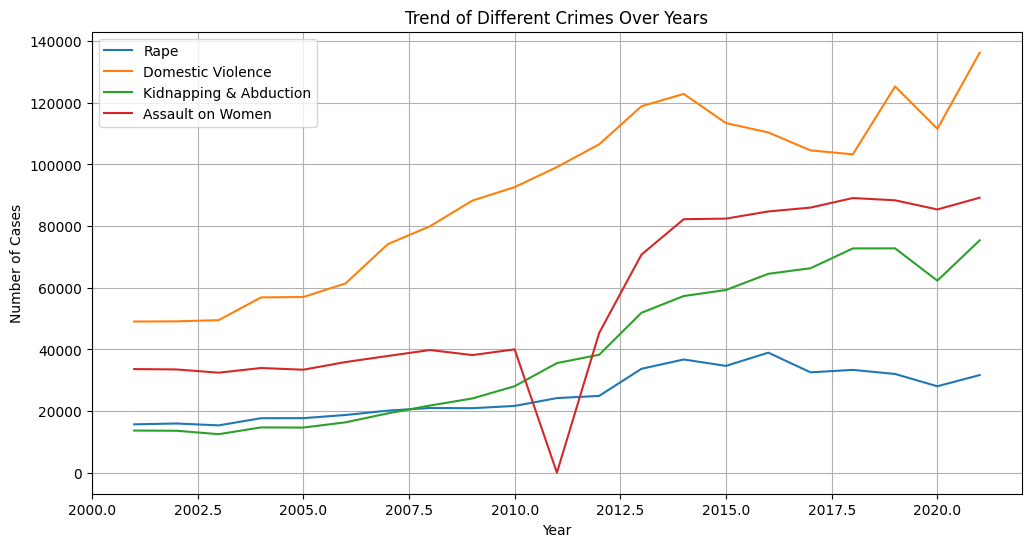

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(yearly_data.index, yearly_data['Rape'], label='Rape')
plt.plot(yearly_data.index, yearly_data['DV'], label='Domestic Violence')
plt.plot(yearly_data.index, yearly_data['K&A'], label='Kidnapping & Abduction')
plt.plot(yearly_data.index, yearly_data['AoW'], label='Assault on Women')

plt.title("Trend of Different Crimes Over Years")
plt.xlabel("Year")
plt.ylabel("Number of Cases")

plt.legend()
plt.grid()

plt.show()

In [ ]:
df.to_csv("crime_cleaned.csv", index=False)